In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from kmodes.kprototypes import KPrototypes
import kmodes
from kmodes.kprototypes import KPrototypes
import time
import pickle
import os
import seaborn as sns
from sklearn.cluster import DBSCAN
import folium

# Data Loading & Sanity Check

In [2]:
df = pd.read_parquet('montgomery_crash_reporting_processed.parquet', engine='pyarrow')

In [3]:
feature_summary = pd.DataFrame({
    'Feature': df.columns,
    'Unique_Values': [df[col].nunique() for col in df.columns],
    'Data_Type': [df[col].dtype for col in df.columns]
})
feature_summary

,Feature,Unique_Values,Data_Type
0,agency_name,6,category
1,acrs_report_type,3,category
2,hit_run,2,Int64
3,route_type,5,category
4,distance,5834,float64
5,at_fault,3,category
6,collision_type,6,category
7,weather,7,category
8,surface_condition,4,category
9,light,6,category


# K-Prototypes Model

## Pipeline

In [4]:
# 1) עמודות קטגוריאליות
categorical_columns = [
    'route_type', 'weather', 'light', 
    'junction', 'road_condition', 'surface_condition',
    'season', 'road_grade_cat', 'road_division_cat', 
    'traffic_control', 'road_alignment_cat', 'division_type', 'time_of_day',
    'left_turn', 'division', 'first_harmful_event', 'second_harmful_event', 
    'at_fault', 'collision_type', 'num_directions', 'lane_category', 'agency_name',
    'is_two_way', 'road_grade_Downhill', 'road_grade_Hillcrest', 'road_grade_Level', 
    'road_grade_On_Bridge', 'road_grade_Other', 'road_grade_Sag', 
    'road_grade_Uphill', 'road_alignment_Curve_Left', 'road_alignment_Curve_Right', 
    'road_alignment_Other', 'road_alignment_Straight', 
    'road_alignment_Not_Relevant', 'road_grade_Not_Relevant',
    'is_weekend', 'is_holiday', 'driver_substance_abuse', 'hit_run' 
]

# 2) עמודות מספריות
numeric_columns = ['distance', 'crash_year', 'hour', 'month', 'day_of_week']

### Categorical Columns

In [5]:
# --- המרה לסטרינג ומילוי ערכים חסרים---
for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].astype(str)
        
        df[col] = df[col].replace(
            ['nan', 'NaN', '<NA>', 'None', 'Nat'], 'Unknown')

In [6]:
categorical_columns_set_1 = ['route_type', 'weather', 'light', 
    'junction', 'road_condition', 'surface_condition', 'at_fault',
    'season', 'traffic_control', 'time_of_day', 'first_harmful_event', 'second_harmful_event',
    'collision_type', 'num_directions', 'lane_category', 'agency_name',
    'is_weekend', 'is_holiday', 'driver_substance_abuse', 'hit_run',
    'division_type', 'left_turn', 'division', 'is_two_way',  
    'road_grade_Downhill', 'road_grade_Hillcrest', 'road_grade_Level', 
    'road_grade_On_Bridge', 'road_grade_Other', 'road_grade_Sag', 
    'road_grade_Uphill', 'road_grade_Not_Relevant', 'road_alignment_Curve_Left',
    'road_alignment_Curve_Right',  'road_alignment_Other', 'road_alignment_Straight', 
    'road_alignment_Not_Relevant'
]
     
categorical_columns_set_2 = ['route_type', 'weather', 'light', 
    'junction', 'road_condition', 'surface_condition', 'at_fault',
    'season', 'traffic_control', 'time_of_day', 'first_harmful_event', 'second_harmful_event',
    'collision_type', 'num_directions', 'lane_category', 'agency_name',
    'is_weekend', 'is_holiday', 'driver_substance_abuse', 'hit_run',
    'road_division_cat', 'road_grade_cat', 'road_alignment_cat'
]

### Numeric Columns

In [7]:
# --- קיטום ---
# מתוך ההנחה: ממש בצומת (0), התקרבות לצומת (0.2), כביש פתוח (0.5-2) ולכן עשינו קיטום למרחק ב2
# כדי לאפשר למודל להבדיל בין תאונות צומת לתאונות דרך.
df['distance'] = df['distance'].clip(upper=2.0)
# --- השלמת חסרים ---
df['distance'] = df['distance'].fillna(df['distance'].median())

# --- נירמול ---
df_model_1 = df[numeric_columns + categorical_columns_set_1].copy()
scaler = StandardScaler()
df_model_1[numeric_columns] = scaler.fit_transform(df_model_1[numeric_columns])

df_model_2 = df[numeric_columns + categorical_columns_set_2].copy()
scaler = StandardScaler()
df_model_2[numeric_columns] = scaler.fit_transform(df_model_2[numeric_columns])

### Model

In [8]:
# data_matrix = df_model.to_numpy()
# cat_columns_indices = [df_model.columns.get_loc(col) for col in categorical_columns]

In [9]:
# # טווח הקלאסטרים שנבדוק (למשל מ-2 עד 7)
# # אם הדאטה ענק והמחשב איטי, אפשר להקטין את הטווח או לדגום חלק מהשורות
# k_range = range(2, 16)
# costs = []

# print("--- Starting Elbow Method ---")
# start_time = time.time()

# for k in k_range:
#     print(f"Running for k={k}...")
    
#     # הגדרת המודל
#     # init='Cao': שיטת אתחול מהירה וטובה ל-K-Prototypes
#     # n_init=1: מריץ פעם אחת לכל K (כדי לחסוך זמן בשלב הבדיקה)
#     kproto = KPrototypes(n_clusters=k, init='Cao', verbose=0, n_init=1, n_jobs=-1)
    
#     # אימון המודל
#     # חשוב מאוד: מעבירים את המטריצה ואת רשימת האינדקסים הקטגוריאליים
#     kproto.fit(data_matrix, categorical=cat_columns_indices)
    
#     # שמירת ה-Cost (המחיר/השגיאה)
#     costs.append(kproto.cost_)

# print(f"\nDone! Total time: {round((time.time() - start_time)/60, 2)} minutes.")

# # --- שלב 2: ציור הגרף ---
# plt.figure(figsize=(10, 6))
# plt.plot(k_range, costs, marker='o', linestyle='--', color='b')
# plt.title('The Elbow Method (Cost vs. K)')
# plt.xlabel('Number of Clusters (K)')
# plt.ylabel('Cost')
# plt.grid(True)
# plt.show()

# # הדפסת הערכים כדי לראות את הירידה במספרים
# for k, cost in zip(k_range, costs):
#     print(f"K={k}: {cost:.2f}")

In [ ]:
# # המרה למערך NumPy שהמודל יודע לקרוא
# data_matrix_1 = df_model_1.to_numpy()

# #שמירת אינדקסים של המשתנים הקטגוריאליים
# current_cat_cols = [c for c in df_model_1.columns if c not in numeric_columns]
# cat_indices = [df_model_1.columns.get_loc(col) for col in current_cat_cols]

# #הגדרת המודל עם הפרמטרים שנבחרו
# kproto_1 = KPrototypes(n_clusters=7, init='Cao', verbose=1, n_init=5, n_jobs=-1)

# #הרצת המודל וקבלת התוצאות
# clusters = kproto_1.fit_predict(data_matrix_1, categorical=cat_indices)

# # יצירת טבלה לניתוח המבוססת על הערכים המקוריים (לפני הנרמול) ובתוספת הקלאסטרים
# df_analysis_1 = df[df_model_1.columns].copy()
# df_analysis_1['cluster'] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Best run was number 2


In [ ]:
# with open('basic_kproto_model_set1_k7.pkl', 'wb') as f:
#     pickle.dump(kproto_1, f)

In [ ]:
data_matrix_1 = df_model_1.to_numpy()

current_cat_cols = [c for c in df_model_1.columns if c not in numeric_columns]
cat_indices = [df_model_1.columns.get_loc(col) for col in current_cat_cols]

with open('basic_kproto_model_set1_k7.pkl', 'rb') as f:
    kproto_1 = pickle.load(f)

clusters = kproto_1.predict(data_matrix_1, categorical=cat_indices)

df_analysis_1 = df[df_model_1.columns].copy()
df_analysis_1['cluster'] = clusters

## Clusters Analysis

### Preliminary Analysis

In [12]:
# ניתוח גודל הקלאסטרים
cluster_stats = df_analysis_1['cluster'].value_counts().reset_index()
cluster_stats.columns = ['Cluster', 'Count']
cluster_stats['Percentage'] = (cluster_stats['Count'] / len(df_analysis_1) * 100).round(2)
cluster_stats = cluster_stats.sort_values('Cluster')
cluster_stats

,Cluster,Count,Percentage
1,0,22774,19.49
5,1,14573,12.47
4,2,16700,14.29
2,3,18925,16.20
6,4,1557,1.33
0,5,24347,20.84
3,6,17966,15.38


In [19]:
# ממוצעים למשתנים הנומריים
numeric_cols_in_model = [c for c in df_model_1.columns if c in numeric_columns]
numeric_profile = df_analysis_1.groupby('cluster')[numeric_cols_in_model].mean().round(2).reset_index()
numeric_profile

,cluster,distance,crash_year,hour,month,day_of_week
0,0,0.02,2018.26,12.42,3.28,1.94
1,1,0.00,2019.82,13.61,6.59,2.87
2,2,0.02,2020.08,5.46,8.15,3.78
3,3,0.01,2019.43,16.75,6.69,5.13
4,4,0.81,2019.26,12.55,6.81,3.08
5,5,0.02,2018.36,15.11,9.73,1.74
6,6,0.01,2024.04,14.82,5.82,2.32


In [16]:
# שכיחים למשתנים הקטגוריאליים
def get_mode(x):
    return x.mode().iloc[0] if not x.mode().empty else 'Unknown'

categorical_profile = df_analysis_1.groupby('cluster')[current_cat_cols].agg(get_mode).reset_index()
display(categorical_profile.T)

,0,1,2,3,4,5,6
cluster,0,1,2,3,4,5,6
route_type,Highway,Parking_Lot,Local,Local,Highway,Highway,Local
weather,Clear,Clear,Clear,Clear,Clear,Clear,Clear
light,Daylight,Daylight,Daylight,Daylight,Daylight,Daylight,Daylight
junction,Intersection,Not Relevant,Non-Junction,Intersection,Non-Junction,Intersection,Non-Junction
road_condition,Normal,Not Relevant,Normal,Normal,Normal,Normal,Normal
surface_condition,Dry,Unknown,Dry,Dry,Dry,Dry,Dry
at_fault,Driver,Driver,Driver,Driver,Driver,Driver,Driver
season,Spring,Summer,Autumn,Summer,Spring,Autumn,Spring
traffic_control,Traffic Signal,Unknown,No Controls,Traffic Signal,No Controls,Traffic Signal,No Controls


In [ ]:
categorical_profile

,cluster,route_type,weather,light,junction,road_condition,surface_condition,at_fault,season,traffic_control,...,road_grade_On_Bridge,road_grade_Other,road_grade_Sag,road_grade_Uphill,road_grade_Not_Relevant,road_alignment_Curve_Left,road_alignment_Curve_Right,road_alignment_Other,road_alignment_Straight,road_alignment_Not_Relevant
0,0,Highway,Clear,Daylight,Intersection,Normal,Dry,Driver,Spring,Traffic Signal,...,0,0,0,0,0,0,0,0,1,0
1,1,Parking_Lot,Clear,Daylight,Not Relevant,Not Relevant,Unknown,Driver,Summer,Unknown,...,0,0,0,0,1,0,0,0,0,1
2,2,Local,Clear,Daylight,Non-Junction,Normal,Dry,Driver,Autumn,No Controls,...,0,0,0,0,0,0,0,0,1,0
3,3,Local,Clear,Daylight,Intersection,Normal,Dry,Driver,Summer,Traffic Signal,...,0,0,0,0,0,0,0,0,1,0
4,4,Highway,Clear,Daylight,Non-Junction,Normal,Dry,Driver,Spring,No Controls,...,0,0,0,0,0,0,0,0,1,0
5,5,Highway,Clear,Daylight,Intersection,Normal,Dry,Driver,Autumn,Traffic Signal,...,0,0,0,0,0,0,0,0,1,0
6,6,Local,Clear,Daylight,Non-Junction,Normal,Dry,Driver,Spring,No Controls,...,0,0,0,0,0,0,0,0,1,0


### In-Depth Analysis

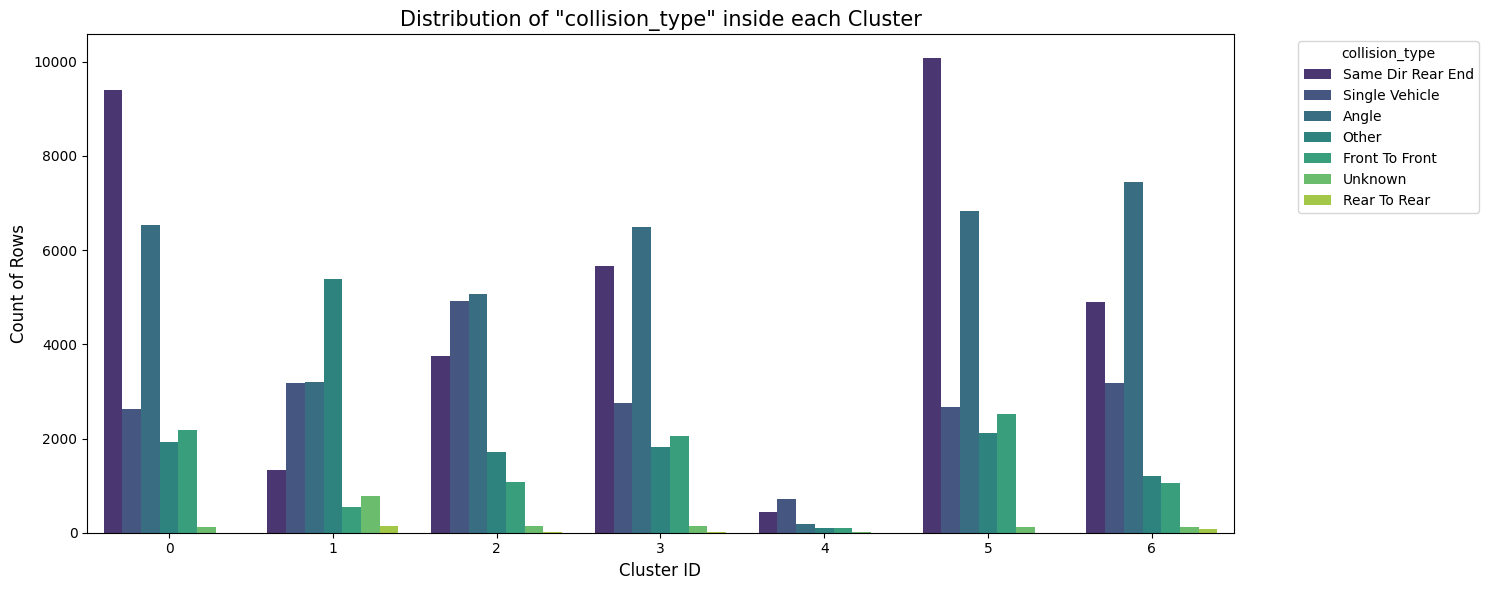

In [33]:
# --- הגדרות משתמש ---
# כאן תשני כל פעם את שם העמודה שאת רוצה לחקור
column_to_plot = 'collision_type' 

# --- יצירת הגרף ---
plt.figure(figsize=(15, 6)) # גרף רחב וברור

# countplot: ציר איקס = קלאסטרים, צבע (hue) = הערכים בעמודה שבחרת
ax = sns.countplot(data=df_analysis_1, x='cluster', hue=column_to_plot, palette='viridis')

# --- עיצוב וכותרות ---
plt.title(f'Distribution of "{column_to_plot}" inside each Cluster', fontsize=15)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Count of Rows', fontsize=12)

# הזזת המקרא (Legend) הצידה שלא יסתיר את הגרף
plt.legend(title=column_to_plot, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

ניתן לראות שסקבוצה 6 יש נתונים בעיקר מ2024-2025, בקבוצה שו יש כל מיני ערכים ייחודיים שמופיעים הרבה יותר מבקבוצות אחרות. ההנחה שלנו היא שבשנים אלו שונו ההנחיות על מילוי הדוח, חויבו למלא יותר בהקפדה את השדות ובחלק מהמקרים המונחים שונו. זה מתאים גם עם הממצא על שינוי צורת הרישום שראינו בפרק preprocessing.

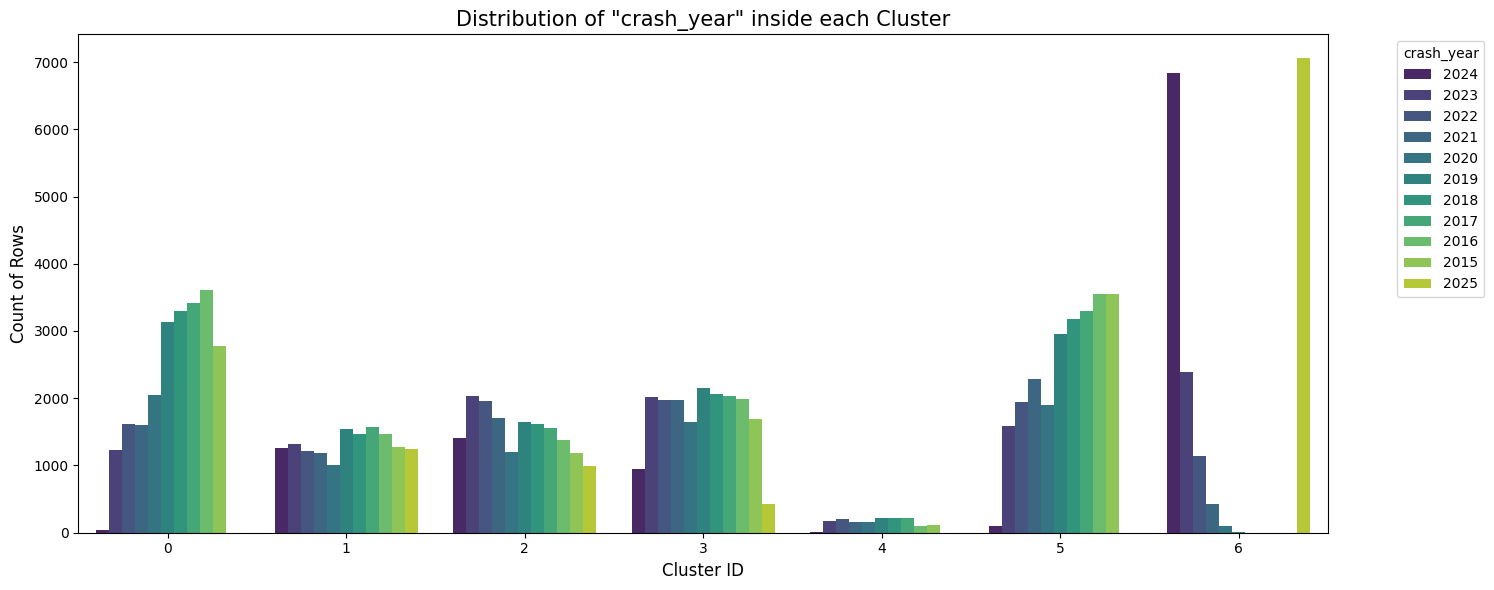

In [32]:
# --- הגדרות משתמש ---
column_to_plot = 'crash_year' 

# --- יצירת עותק זמני לציור (כדי לא לשנות את הדאטה המקורי) ---
df_plot = df_analysis_1.copy()

# התיקון: המרה ל-String (טקסט) כדי שהגרף יבין שאלו קטגוריות ולא מספרים מורכבים
df_plot[column_to_plot] = df_plot[column_to_plot].astype(str)

# --- יצירת הגרף ---
plt.figure(figsize=(15, 6))

# שימי לב: אני משתמש ב-df_plot ולא ב-df_analysis_1
ax = sns.countplot(data=df_plot, x='cluster', hue=column_to_plot, palette='viridis')

# --- עיצוב וכותרות ---
plt.title(f'Distribution of "{column_to_plot}" inside each Cluster', fontsize=15)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Count of Rows', fontsize=12)

# הזזת המקרא
plt.legend(title=column_to_plot, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

ניתן לראות שבקבוצה 3 יש שני מאפיינים ייחודיים שבולטים: יש יותר תאונות פגע וברח, ככל הנראה בגלל חומרת התאונה והמיקום (חניונים). בנוסף,קבוצה זו מכילה באופן מפתיעה הרבה תאונות של פנים לפנים. מבדיקה אנו רואים שלא מדובר בתאונות חומרות והן כנראה נובעות מהתנהגות בחניה ומבנה חניונים שבחלקו יש בעיה בשדה הראייה.

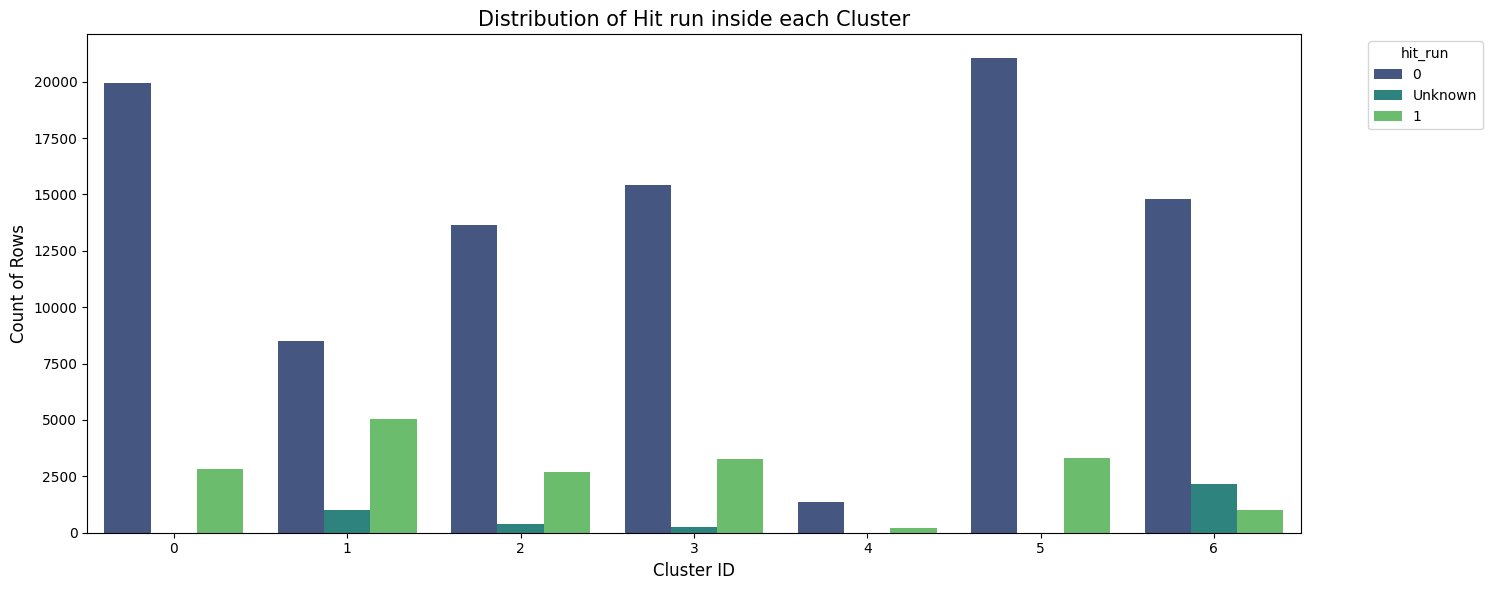

In [28]:
plt.figure(figsize=(15, 6)) # גרף רחב וברור
ax = sns.countplot(data=df_analysis_1, x='cluster', hue='hit_run', palette='viridis')

plt.title(f'Distribution of Hit run inside each Cluster', fontsize=15)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Count of Rows', fontsize=12)

plt.legend(title=column_to_plot, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

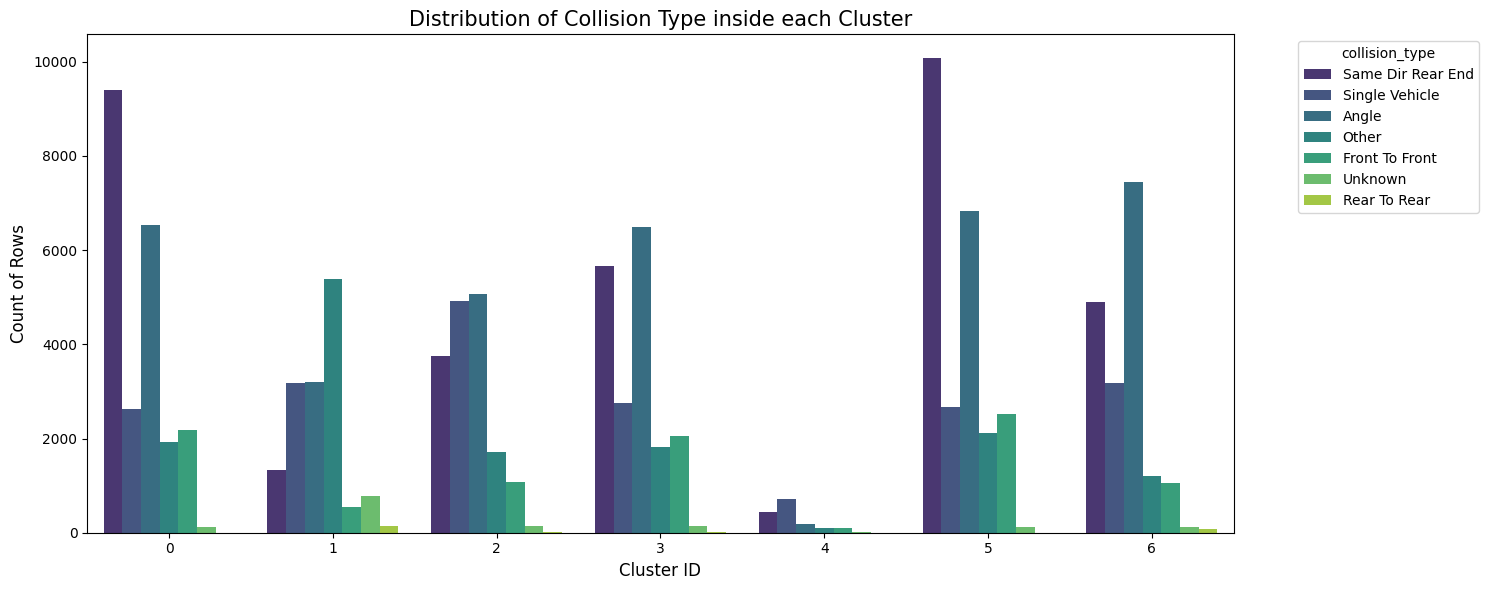

In [37]:
plt.figure(figsize=(15, 6)) # גרף רחב וברור
ax = sns.countplot(data=df_analysis_1, x='cluster', hue='collision_type', palette='viridis')

plt.title(f'Distribution of Collision Type inside each Cluster', fontsize=15)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Count of Rows', fontsize=12)

plt.legend(title=column_to_plot, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [41]:
df['cluster'] = df_analysis_1['cluster']

pd.crosstab(df[df['cluster'] == 1]['collision_type'], df[df['cluster'] == 1]['acrs_report_type'])

acrs_report_type,Fatal Crash,Injury Crash,Property Damage Crash
collision_type,,,
Angle,0,397,2811
Front To Front,0,97,448
Other,4,745,4631
Rear To Rear,0,5,145
Same Dir Rear End,0,159,1182
Single Vehicle,2,923,2251
Unknown,0,55,718


## Subset Analysis: 2024-2025

In [48]:
indices_new_rep = df[df['crash_year'] > 2023].index
df_new_rep = df_model_1.loc[indices_new_rep].copy()

In [49]:
# המרה למערך NumPy שהמודל יודע לקרוא
data_matrix_new_rp = df_new_rep.to_numpy()

#שמירת אינדקסים של המשתנים הקטגוריאליים
current_cat_cols = [c for c in df_new_rep.columns if c not in numeric_columns]
cat_indices = [df_new_rep.columns.get_loc(col) for col in current_cat_cols]

#הגדרת המודל עם הפרמטרים שנבחרו
kproto_new_rep = KPrototypes(n_clusters=7, init='Cao', verbose=1, n_init=5, n_jobs=-1)

#הרצת המודל וקבלת התוצאות
clusters = kproto_new_rep.fit_predict(data_matrix_new_rp, categorical=cat_indices)

# יצירת טבלה לניתוח המבוססת על הערכים המקוריים (לפני הנרמול) ובתוספת הקלאסטרים
df_analysis_new_rep = df.loc[df_new_rep.index].copy()
df_analysis_new_rep['cluster'] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Best run was number 3


In [50]:
with open('new_rep_kproto_model_set1_k7.pkl', 'wb') as f:
    pickle.dump(kproto_new_rep, f)

### Preliminary Analysis

In [51]:
# ניתוח גודל הקלאסטרים
cluster_stats = df_analysis_new_rep['cluster'].value_counts().reset_index()
cluster_stats.columns = ['Cluster', 'Count']
cluster_stats['Percentage'] = (cluster_stats['Count'] / len(df_analysis_new_rep) * 100).round(2)
cluster_stats = cluster_stats.sort_values('Cluster')
cluster_stats

,Cluster,Count,Percentage
1,0,3445,16.94
3,1,2912,14.32
5,2,2381,11.71
2,3,3369,16.57
6,4,1663,8.18
4,5,2878,14.15
0,6,3688,18.14


In [52]:
# ממוצעים למשתנים הנומריים
numeric_cols_in_model = [c for c in df_analysis_new_rep.columns if c in numeric_columns]
numeric_profile = df_analysis_new_rep.groupby('cluster')[numeric_cols_in_model].mean().round(2).reset_index()
numeric_profile

,cluster,distance,crash_year,hour,month,day_of_week
0,0,0.01,2024.49,11.42,3.23,1.19
1,1,0.00,2024.47,8.3,9.32,2.02
2,2,0.00,2024.5,13.91,6.4,2.81
3,3,0.00,2024.48,17.2,8.93,1.42
4,4,0.01,2024.46,4.19,5.73,4.98
5,5,0.00,2024.46,16.29,9.18,5.01
6,6,0.00,2024.48,16.93,3.42,3.92


In [53]:
# שכיחים למשתנים הקטגוריאליים
def get_mode(x):
    return x.mode().iloc[0] if not x.mode().empty else 'Unknown'

categorical_profile = df_analysis_new_rep.groupby('cluster')[current_cat_cols].agg(get_mode).reset_index()
categorical_profile

,cluster,route_type,weather,light,junction,road_condition,surface_condition,at_fault,season,traffic_control,...,road_grade_On_Bridge,road_grade_Other,road_grade_Sag,road_grade_Uphill,road_grade_Not_Relevant,road_alignment_Curve_Left,road_alignment_Curve_Right,road_alignment_Other,road_alignment_Straight,road_alignment_Not_Relevant
0,0,Local,Clear,Daylight,Non-Junction,Normal,Dry,Driver,Spring,No Controls,...,0,0,0,0,0,0,0,0,1,0
1,1,Highway,Clear,Daylight,Non-Junction,Normal,Dry,Driver,Autumn,Traffic Signal,...,0,0,0,0,0,0,0,0,1,0
2,2,Parking_Lot,Clear,Daylight,Not Relevant,Not Relevant,Unknown,Unknown,Summer,Unknown,...,0,0,0,0,1,0,0,0,0,1
3,3,Local,Clear,Daylight,Non-Junction,Normal,Dry,Driver,Autumn,No Controls,...,0,0,0,0,0,0,0,0,1,0
4,4,Local,Clear,Dark Lighted,Non-Junction,Normal,Dry,Driver,Spring,No Controls,...,0,0,0,0,0,0,0,0,1,0
5,5,Local,Clear,Daylight,Non-Junction,Normal,Dry,Driver,Autumn,No Controls,...,0,0,0,0,0,0,0,0,1,0
6,6,Local,Clear,Daylight,Non-Junction,Normal,Dry,Driver,Spring,Traffic Signal,...,0,0,0,0,0,0,0,0,1,0


### In-Depth Analysis

# DBSCAN Model

### Sub-Clustering: Open Road Cluster

In [54]:
indices_cluster_4 = df_analysis_1[df_analysis_1['cluster'] == 4].index
geo_data_cl4 = df.loc[indices_cluster_4, ['latitude', 'longitude']].dropna().copy()
geo_matrix_cl4 = np.radians(geo_data_cl4.to_numpy())

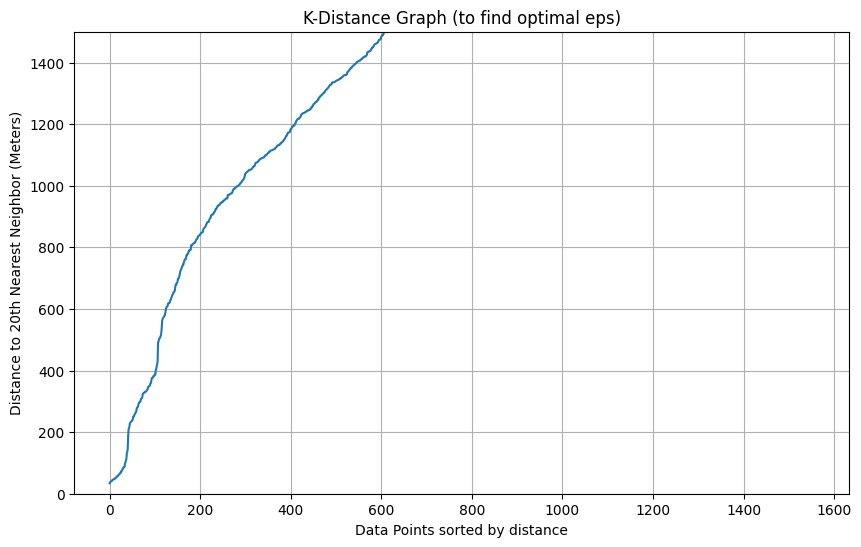

In [55]:
# הגדרת מספר השכנים לבדיקה (min_samples - 1)
n_neighbors = 20 

# חישוב המרחק ל-20 השכנים הקרובים לכל נקודה
nbrs = NearestNeighbors(n_neighbors=n_neighbors, metric='haversine').fit(geo_matrix_cl4)
distances, indices = nbrs.kneighbors(geo_matrix_cl4)

# מיון המרחקים (של השכן ה-20) מהקטן לגדול כדי לצייר גרף
distances = np.sort(distances[:, n_neighbors-1])

# המרה מרדיאנים למטרים כדי שנבין מה אנחנו רואים בגרף
# רדיוס כדור הארץ הוא בערך 6371 ק"מ = 6,371,000 מטרים
earth_radius_meters = 6371000
distances_meters = distances * earth_radius_meters

# --- ציור הגרף ---
plt.figure(figsize=(10, 6))
plt.plot(distances_meters)
plt.title('K-Distance Graph (to find optimal eps)')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Distance to 20th Nearest Neighbor (Meters)')
plt.grid(True)

# זום-אין לאזור המעניין (אופציונלי, כדי לראות את הברך טוב יותר)
# בדרך כלל ה"זנב" עולה לשמיים ומסתיר את הברך, אז נגביל את ציר ה-Y
plt.ylim(0, 1500) # מציג עד 1500 מטר

plt.show()

In [61]:
kms_per_radian = 6371.0088
epsilon_meters = 300            
epsilon_radians = epsilon_meters / 1000 / kms_per_radian 
min_samples = 20                

print(f"Running DBSCAN on {len(geo_data_cl4)} accidents...")

# 2. הרצת המודל על המטריצה המוכנה שלך
db = DBSCAN(eps=epsilon_radians, min_samples=min_samples, algorithm='ball_tree', metric='haversine')
db.fit(geo_matrix_cl4)

# 3. שמירת התוצאות
# נשמור את התוצאות ישירות לדאטה-פריים שיצרת
geo_data_cl4['dbscan_cluster'] = db.labels_

# 4. ניתוח התוצאות
n_clusters_ = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise_ = list(db.labels_).count(-1)

print(f'\nResults:')
print(f'Estimated number of clusters (Red Roads): {n_clusters_}')
print(f'Estimated number of noise points: {n_noise_}')

# הצצה לגודל הקלאסטרים שנמצאו
print("\nTop clusters found (Cluster ID : Size):")
print(geo_data_cl4[geo_data_cl4['dbscan_cluster'] != -1]['dbscan_cluster'].value_counts().head())

Running DBSCAN on 1557 accidents...

Results:
Estimated number of clusters (Red Roads): 4
Estimated number of noise points: 1449

Top clusters found (Cluster ID : Size):
dbscan_cluster
0    44
2    24
1    20
3    20
Name: count, dtype: int64


In [65]:
# 1. חישוב מרכז המפה
center_lat = geo_data_cl4['latitude'].mean()
center_lon = geo_data_cl4['longitude'].mean()

print(f"Map centered at: {center_lat}, {center_lon}")

m = folium.Map(location=[center_lat, center_lon], zoom_start=11)

colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'black', 'pink']

# 2. הוספת הנקודות
for index, row in geo_data_cl4.iterrows():
    cluster_id = row['dbscan_cluster']
    
    if cluster_id == -1:
        continue 
        
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6,
        # התיקון הוא כאן: הוספנו int(...)
        color=colors[int(cluster_id) % len(colors)], 
        fill=True,
        fill_opacity=0.8,
        popup=f'Cluster {int(cluster_id)}'
    ).add_to(m)
m.save('cluster4_clusters_map.html')

m

Map centered at: 39.12745332035324, -77.16966113478485


### Global DBSCAN

Total rows for analysis: 116842
Calculating Nearest Neighbors (this might take a moment)...


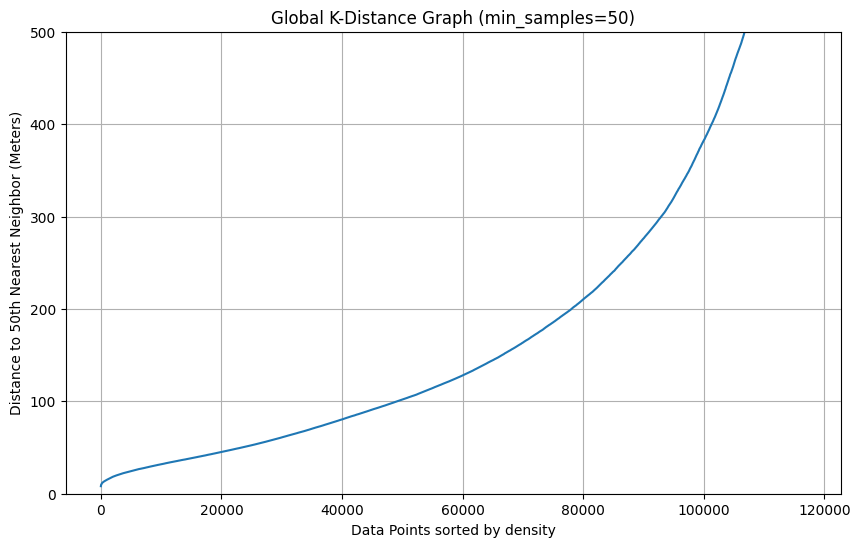

In [66]:
# 1. הכנת כל הדאטה (ללא סינון לקלאסטר ספציפי)
# לוקחים את כל ה-117,000, אבל זורקים רק את אלו בלי GPS
geo_data_all = df[['latitude', 'longitude']].dropna().copy()
geo_matrix_all = np.radians(geo_data_all.to_numpy())

print(f"Total rows for analysis: {len(geo_data_all)}")

# 2. הגדרת מספר השכנים החדש (הגדלנו כי הדאטה ענק)
n_neighbors = 50 

print("Calculating Nearest Neighbors (this might take a moment)...")

# 3. חישוב המרחקים
nbrs_all = NearestNeighbors(n_neighbors=n_neighbors, metric='haversine').fit(geo_matrix_all)
distances_all, indices_all = nbrs_all.kneighbors(geo_matrix_all)

# 4. מיון והמרה למטרים
distances_all = np.sort(distances_all[:, n_neighbors-1])
earth_radius_meters = 6371000
distances_meters_all = distances_all * earth_radius_meters

# 5. ציור הגרף
plt.figure(figsize=(10, 6))
plt.plot(distances_meters_all)
plt.title(f'Global K-Distance Graph (min_samples={n_neighbors})')
plt.xlabel('Data Points sorted by density')
plt.ylabel(f'Distance to {n_neighbors}th Nearest Neighbor (Meters)')
plt.grid(True)

# זום: כאן אני מנחש שהברך תהיה נמוכה, אז נגביל ל-200 מטר כדי לראות טוב
plt.ylim(0, 500) 

plt.show()

In [67]:
epsilon_meters = 150            
kms_per_radian = 6371.0088
epsilon_radians = epsilon_meters / 1000 / kms_per_radian 

# החלטנו על 50 תאונות מינימום כדי לסנן "סתם רעש"
min_samples = 50                

print(f"Running Global DBSCAN on {len(geo_data_all)} accidents...")
print(f"Parameters: Epsilon={epsilon_meters}m, Min Samples={min_samples}")

# 2. הרצת המודל
db_global = DBSCAN(eps=epsilon_radians, min_samples=min_samples, algorithm='ball_tree', metric='haversine')
db_global.fit(geo_matrix_all)

# 3. שמירת התוצאות
# ניצור עותק של הדאטה כדי לשמור את התוצאות
geo_data_all['global_cluster'] = db_global.labels_

# 4. ניתוח התוצאות
n_clusters_global = len(set(db_global.labels_)) - (1 if -1 in db_global.labels_ else 0)
n_noise_global = list(db_global.labels_).count(-1)
noise_percent = (n_noise_global / len(geo_data_all)) * 100

print(f'\nGlobal Analysis Results:')
print(f'Estimated number of clusters found: {n_clusters_global}')
print(f'Points classified as Noise: {n_noise_global} ({noise_percent:.1f}%)')

# הצצה לקלאסטרים הגדולים ביותר (למשל: מרכז העיר יהיה קלאסטר ענק)
print("\nTop 10 Largest Clusters (Cluster ID : Size):")
print(geo_data_all[geo_data_all['global_cluster'] != -1]['global_cluster'].value_counts().head(10))

Running Global DBSCAN on 116842 accidents...
Parameters: Epsilon=150m, Min Samples=50

Global Analysis Results:
Estimated number of clusters found: 220
Points classified as Noise: 36987 (31.7%)

Top 10 Largest Clusters (Cluster ID : Size):
global_cluster
7     6806
8     6485
36    6267
4     5364
41    3274
31    2577
17    2138
13    2081
39    2039
24    2001
Name: count, dtype: int64


In [68]:
# 1. יצירת טבלת סיכום לכל קלאסטר (גודל + מיקום המרכז שלו)
# מסננים את הרעש (-1) לפני החישוב
df_clean = geo_data_all[geo_data_all['global_cluster'] != -1]

cluster_summary = df_clean.groupby('global_cluster').agg({
    'latitude': 'mean',
    'longitude': 'mean',
    'global_cluster': 'size' # סופר כמה תאונות יש בכל קלאסטר
}).rename(columns={'global_cluster': 'accident_count'})

# 2. יצירת המפה
center_lat = cluster_summary['latitude'].mean()
center_lon = cluster_summary['longitude'].mean()
m_global = folium.Map(location=[center_lat, center_lon], zoom_start=10)

# 3. הוספת הקלאסטרים למפה עם הבדלה בצבעים
for cluster_id, row in cluster_summary.iterrows():
    count = row['accident_count']
    lat = row['latitude']
    lon = row['longitude']
    
    # לוגיקה לצבעים וגודל
    if count > 1000:
        # מגה-קלאסטר (עיר/שכונה)
        color = 'blue'
        radius = 10
        popup_text = f"Mega Zone {cluster_id}: {count} accidents"
    else:
        # נקודה חמה ספציפית (צומת/מחלף) - זה מה שמעניין אותנו!
        color = 'red'
        radius = 6
        popup_text = f"Hotspot {cluster_id}: {count} accidents"
        
    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=popup_text
    ).add_to(m_global)

# 4. שמירה והצגה
m_global.save('global_hotspots_map.html')
m_global